# Import Modules and Functions

In [3]:
from LC_utility import *

In [4]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [6]:
## reference tables
table_a57 = pd.read_csv('LC_tables/data/LCref_a57_g.csv')
table_a54 = pd.read_csv('LC_tables/data/LCref_a54_g.csv')

## segment 1
lc_data1 = pd.read_csv('LC_tables/data/LCtable1_g.csv')

## segment 2
lc_data2 = pd.read_csv('LC_tables/data/LCtable2_g.csv')

## segment 3
lc_data3 = pd.read_csv('LC_tables/data/LCtable3_g.csv')

## segment 4
lc_data4 = pd.read_csv('LC_tables/data/LCtable4_g.csv')

In [7]:
### Some images need to be excluded due to quality
### Images from ccd 54 have bad bands (mainly filter i is affected)

## filter g
badims_a54g = pd.read_csv('txt_files/ec0915a54g_badims.txt', header=None)[0]
bad_expnums_a54g = [float(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54g]

## filter r
bad_expnums_a54r = None

## filter i
badims_a54i = pd.read_csv('txt_files/ec0915a54i_badims.txt', header=None)[0]
bad_expnums_a54i = [float(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54i]

## filter z
bad_expnums_a54z = None

In [8]:
### Read in iteration 1 LC model
LCmodel1 = pd.read_csv('LC_tables/models/gLC_m1.csv')

# Combine LCs

### Fitting Process for Each Segment

In [11]:
### Define uncertainty/error cuts

## segment 1
n_sigs1 = None                               # n-sigma cuts based on micro-Jyas2 and its error
mJyas2_lms1 = [10.0, 1.0]                    # upperlimits on micro-Jyas2 and its error

## segment 2
n_sigs2 = None
mJyas2_lms2 = [40.0, 1.0]

## segment 3
n_sigs3 = None
mJyas2_lms3 = [4.0, 1.0]

## segment 4
n_sigs4 = None
mJyas2_lms4 = [3.0, 1.0]

In [12]:
### Fit LCs to a template
### 2nd iteration --> template is the model LC

### Use same tshifts as in filter i
i2parms1 = pd.read_csv('LC_tables/fit_params/f2params_i1.csv').values
i2parms2 = pd.read_csv('LC_tables/fit_params/f2params_i2.csv').values
i2parms3 = pd.read_csv('LC_tables/fit_params/f2params_i3.csv').values
i2parms4 = pd.read_csv('LC_tables/fit_params/f2params_i4.csv').values

## segment 1
fit_parms1 = fit_LCs(lc_data1, LCmodel=LCmodel1, n_sigmas=n_sigs1, mJyas2_lms=mJyas2_lms1, tshift_ls=i2parms1[1])

## segment 2
fit_parms2 = fit_LCs(lc_data2, LCmodel=LCmodel1, n_sigmas=n_sigs2, mJyas2_lms=mJyas2_lms2, bad_expnums=bad_expnums_a54g, tshift_ls=i2parms2[1])

## segment 3
fit_parms3 = fit_LCs(lc_data3, LCmodel=LCmodel1, n_sigmas=n_sigs3, mJyas2_lms=mJyas2_lms3, bad_expnums=bad_expnums_a54g, tshift_ls=i2parms3[1])

## segment 4
fit_parms4 = fit_LCs(lc_data4, LCmodel=LCmodel1, n_sigmas=n_sigs4, mJyas2_lms=mJyas2_lms4, bad_expnums=bad_expnums_a54g, tshift_ls=i2parms4[1])

In [13]:
### Create data frame of aligned LCs

## segment 1
comb1 = get_alignedLCs(lc_data1, fit_parms1, LCmodel=LCmodel1, n_sigmas=n_sigs1, mJyas2_lms=mJyas2_lms1)

## segment 2
comb2 = get_alignedLCs(lc_data2, fit_parms2, LCmodel=LCmodel1, n_sigmas=n_sigs2, mJyas2_lms=mJyas2_lms2, bad_expnums=bad_expnums_a54g)

## segment 3
comb3 = get_alignedLCs(lc_data3, fit_parms3, LCmodel=LCmodel1, n_sigmas=n_sigs3, mJyas2_lms=mJyas2_lms3, bad_expnums=bad_expnums_a54g)

## segment 4
comb4 = get_alignedLCs(lc_data4, fit_parms4, LCmodel=LCmodel1, n_sigmas=n_sigs4, mJyas2_lms=mJyas2_lms4, bad_expnums=bad_expnums_a54g)

In [14]:
### Create combined LC
### Use sigmacutloop function in pdastro to calculate mean

## segment 1
t_means1, f_means1, f_merrs1, o_params1 = get_combinedLC(comb1, bn_sz=30)
    # o_params --> other parameters --> stdev, stdev_err, chi2, ix_good, ix_bad
    # w_inds --> indices of data points used for combination after sigma-cut
w_inds1 = [i for ix in o_params1[3] for i in ix]

## segment 2
t_means2, f_means2, f_merrs2, o_params2 = get_combinedLC(comb2, bn_sz=30)
w_inds2 = [i for ix in o_params2[3] for i in ix]

## segment 3
t_means3, f_means3, f_merrs3, o_params3 = get_combinedLC(comb3, bn_sz=30)
w_inds3 = [i for ix in o_params3[3] for i in ix]

## segment 4
t_means4, f_means4, f_merrs4, o_params4 = get_combinedLC(comb4, bn_sz=30)
w_inds4 = [i for ix in o_params4[3] for i in ix]

### See/Check Fitting Process

In [16]:
### See individual LCs

# ## 4 segments (labelled 1-4)
# df = lc_data1
# # df = lc_data2

# n_s = n_sigs1
# mJy_lm = mJyas2_lms1

# plot_lcs(df, n_sigmas=n_s, mJyas2_lms=mJy_lm)
# plot_lcs(df, n_sigmas=n_s, mJyas2_lms=mJy_lm, plt_xl=60400)

In [17]:
### See Fitting Process

# df = lc_data1
# # df = lc_data2

# fit_ps = fit_parms1
# n_s = n_sigs1
# mJy_lm = mJyas2_lms1

# plot_LCfits(df,fit_ps, LCmodel=LCmodel1, n_sigmas=n_s, mJyas2_lms=mJy_lm)

In [18]:
### See aligned LCs

# df = lc_data1
# # df = lc_data2

# fit_ps = fit_parms1
# n_s = n_sigs1
# mJy_lm = mJyas2_lms1

# for i in fit_ps[0]:
#     df_inds = get_LCinds(df, lc_ID=i, n_sigmas=n_s, mJyas2_lms=mJy_lm)
#     plt.errorbar(df.loc[df_inds,'new_mjd'], df.loc[df_inds,'new_mJyas2'], yerr=df.loc[df_inds,'new_mJyas2_err'], fmt='.-', ecolor='black')

In [19]:
### See combined LC

# comb_d = comb1
# winds = w_inds1

# t_mns = t_means1
# f_mns = f_means1
# # f_mers = f_merrs1

# plt.errorbar(comb_d.t.loc[winds,'mjd'], comb_d.t.loc[winds,'mJyas2'], fmt='.-', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(t_mns, f_mns, fmt='--o', ecolor='black', color='orange') #,yerr=f_mers
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# plt.show()

# Model LC

### Combine Segments

In [22]:
### Combine Segments
    ## Model data already connected in iteration 2
    ## Combine LC data

tls_m = np.concatenate([comb1.t.loc[w_inds1,'mjd'].values, comb2.t.loc[w_inds2,'mjd'].values, comb3.t.loc[w_inds3,'mjd'].values, comb4.t.loc[w_inds4,'mjd'].values])
fls_m = np.concatenate([comb1.t.loc[w_inds1,'mJyas2'].values, comb2.t.loc[w_inds2,'mJyas2'].values, comb3.t.loc[w_inds3,'mJyas2'].values, comb4.t.loc[w_inds4,'mJyas2'].values])
ferrls_m = np.concatenate([comb1.t.loc[w_inds1,'mJyas2_err'].values, comb2.t.loc[w_inds2,'mJyas2_err'].values, comb3.t.loc[w_inds3,'mJyas2_err'].values, comb4.t.loc[w_inds4,'mJyas2_err'].values])

ord_inds_m = tls_m.argsort()
tls_m = tls_m[ord_inds_m]
fls_m = fls_m[ord_inds_m]
ferrls_m = ferrls_m[ord_inds_m]

comb_m_data = {'mjd': tls_m, 'mJyas2': fls_m, 'mJyas2_err': ferrls_m}
comb_m = pdastrostatsclass()
comb_m.t = comb_m.t.assign(**comb_m_data)

comb_m.t['phase'] = comb_m.t['mjd'] - 57430.

In [23]:
### Create the model (LC_0)

t_model, f_model, ferr_model, o_params_m = get_combinedLC(comb_m, bn_sz=30)
phase_m = t_model - 57430.
w_inds_m = [i for bn in o_params_m[3] for i in bn]

comb_m.t['4model_flag'] = False
comb_m.t.loc[w_inds_m,'4model_flag'] = True
comb_m.t['4model_flag'] = comb_m.t['4model_flag'].astype('bool')

lc_model = {'mjd':t_model, 'mJyas2':f_model, 'mJyas2_err':ferr_model, 'phase':phase_m}
lc_model_d = pd.DataFrame(lc_model)

lc_model_d.to_csv('LC_tables/models/gLC_m2.csv', index=False)

## Save table for bookkeeping purposes
comb_m.t.to_csv('LC_tables/models/gLC_data2.csv', index=False)

### See Model Fitting

In [25]:
### Individual Segements

# fig, axs = plt.subplots(4,1, dpi = 100, figsize = [8,8], sharex=True)

# axs = axs.flatten()
# axs[3].set_xlabel('MJD (days)')

# axs[0].errorbar(t_means1, f_means1, yerr=f_merrs1, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')
# axs[1].errorbar(t_means2, f_means2, yerr=f_merrs2, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')
# axs[2].errorbar(t_means3, f_means3, yerr=f_merrs3, fmt='--o', ecolor='black', color='red', label='Loc 3')
# axs[3].errorbar(t_means4, f_means4, yerr=f_merrs4, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# for ax in axs:
#     ax.minorticks_on()
#     ax.tick_params(axis='x', labelsize=12)
#     ax.tick_params(axis='y', labelsize=12)
#     ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=8)
#     ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=3)
#     ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
#     ax.legend(fontsize = 14)

# # # pl_fig.savefig('../figures/display/EtaCar_PiecesM.png', bbox_inches = 'tight', dpi=100)

In [26]:
### See Connected Segments

# fig, ax = plt.subplots(dpi = 100, figsize = [8,5])
# ax.minorticks_on()
# ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12)
# ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
# ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# ax.set_xlabel('MJD (days)', fontsize = 14)
# ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
# ax.ticklabel_format(axis='both', style='plain')


# ax.errorbar(t_means1, f_means1, yerr=f_merrs1, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')
# ax.errorbar(t_means2, f_means2, yerr=f_merrs2, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')
# ax.errorbar(t_means3, f_means3, yerr=f_merrs3, fmt='--o', ecolor='black', color='red', label='Loc 3')
# ax.errorbar(t_means4, f_means4, yerr=f_merrs4, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# ax.axhline(y=0, ls='--', color='k')

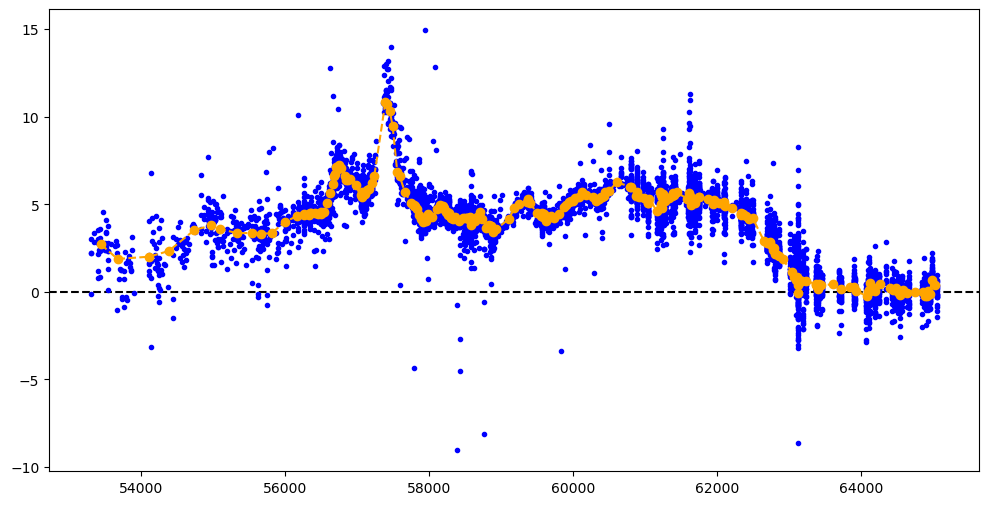

In [27]:
### Plot Model

plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_m.t.loc[w_inds_m,'mjd'], comb_m.t.loc[w_inds_m,'mJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(t_model, f_model, fmt='--o', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')